# FIFA World Cup 2026: Full Tournament Predictions
By Karl Estampador :)

Simulates all 104 matches using the Elo-based model from whatever model is selected.  
The higher-Elo team always advances.  
Third-place bracket allocation follows FIFA's official 495-combination lookup table.

Imports OK
WC matches 2002 - 2022: 384
Matches per tournament:
year
2002    64
2006    64
2010    64
2014    64
2018    64
2022    64
Name: count, dtype: int64

Shootout records in same period: 310

train.csv rows: 192 | test.csv rows: 48
Team names normalised: 6 cells remapped
          date home_team         home_team_norm
11  2002-06-04     China               China PR
71  2006-06-11    Serbia  Serbia and Montenegro
           date away_team         away_team_norm
23   2002-06-08     China               China PR
43   2002-06-13     China               China PR
84   2006-06-16    Serbia  Serbia and Montenegro
101  2006-06-21    Serbia  Serbia and Montenegro

Rows before join: 384
Rows dropped (team not in train.csv): 0
Rows remaining: 384
Class distribution:
outcome
home_win    181
away_win    136
draw         67
Name: count, dtype: int64

Total training matches: 384
Rows dropped for NaN features: 64
  (squad_total_market_value_eur was not recorded for 2002 - all 64 matches from that

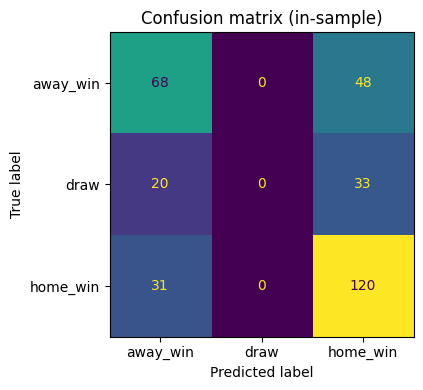

Chart saved to outputs\lr_coefficients.png


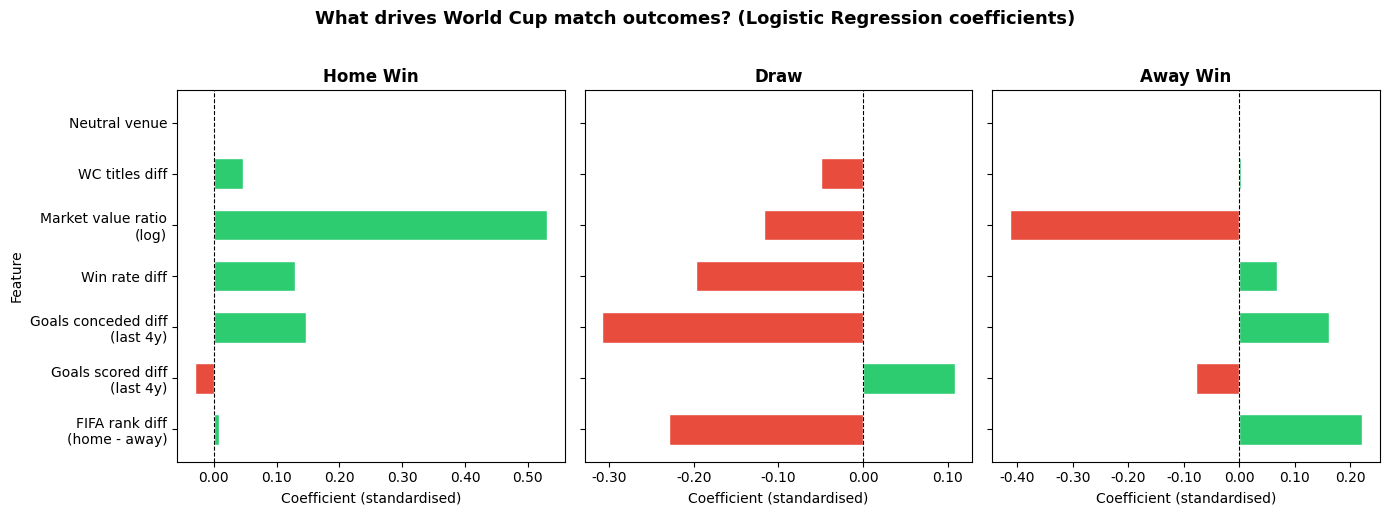

ELO lookup ready (48 teams)
LR test features loaded for 55 name variants
predict_group_match, predict_knockout_winner, get_lr_proba - ready.
predict_winner and predict_score aliased to LR versions.
-- Group match (draws allowed) --
Match                        Result   Winner/Draw    Proba (hw / d / aw)
---------------------------------------------------------------------------
Mexico vs South Africa       2-0     Mexico         hw=0.63  d=0.17  aw=0.19
South Korea vs Czechia            1-0     South Korea    hw=0.45  d=0.22  aw=0.32
Canada vs Bosnia and Herzegovina 0-1     Bosnia and Herzegovina hw=0.27  d=0.33  aw=0.40
United States vs Paraguay           1-0     United States  hw=0.57  d=0.13  aw=0.29

-- Knockout (no draws) --
Match                        Winner         Win Prob
-------------------------------------------------------
Mexico vs South Africa       Mexico         0.635
Mexico vs South Africa       Mexico         1-0      hw=0.57  d=0.13  aw=0.29
South Korea vs Czechia 

In [49]:
# Load model functions and data
%run lr_model.ipynb

In [50]:
import pandas as pd
from pathlib import Path

DATA = Path('data')

# Load schedule and team registry
matches_df = pd.read_csv(DATA / 'matches.csv')
teams_df   = pd.read_csv(DATA / 'teams.csv')

# Build team-ID -> name lookup
id_to_name: dict[int, str] = dict(zip(teams_df['id'], teams_df['team_name']))
name_to_group: dict[str, str] = dict(zip(teams_df['team_name'], teams_df['group_letter']))

alloc_df = pd.read_csv(DATA / 'third_place_allocation.csv')

print(f'{len(matches_df)} matches loaded | {len(teams_df)} teams | allocation table: {len(alloc_df)} rows')

104 matches loaded | 48 teams | allocation table: 495 rows


---
## 1. Group Stage Simulation

In [51]:
group_matches = matches_df[matches_df['stage_id'] == 1].copy()

gs_results = []   # list of dicts, one per group-stage match

for _, row in group_matches.iterrows():
    home = id_to_name[int(row['home_team_id'])]
    away = id_to_name[int(row['away_team_id'])]
    hg, ag, winner = predict_group_match(home, away)
    gs_results.append({
        'match':      int(row['match_number']),
        'group':      row['match_label'],
        'home':       home,
        'away':       away,
        'home_goals': hg,
        'away_goals': ag,
        'winner':     winner if winner else 'Draw',
    })

gs_df = pd.DataFrame(gs_results)
print(f'{len(gs_df)} group-stage matches simulated')

72 group-stage matches simulated


### Group Stage Results

In [52]:
display_gs = gs_df[['match','group','home','home_goals','away_goals','away','winner']].copy()
display_gs.columns = ['Match','Group','Home','HG','AG','Away','Winner']

pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 30)

display_gs

,Match,Group,Home,HG,AG,Away,Winner
0,1,Group A,Mexico,2,0,South Africa,Mexico
1,2,Group A,South Korea,1,0,Czechia,South Korea
2,3,Group B,Canada,0,1,Bosnia and Herzegovina,Bosnia and Herzegovina
3,4,Group D,USA,1,0,Paraguay,USA
4,5,Group B,Qatar,0,2,Switzerland,Switzerland
5,6,Group C,Brazil,1,0,Morocco,Brazil
6,7,Group C,Haiti,0,2,Scotland,Scotland
7,8,Group D,Australia,0,2,Turkey,Turkey
8,9,Group E,Germany,2,0,Curaçao,Germany
9,10,Group F,Netherlands,2,0,Japan,Netherlands


---
## 2. Group Standings

In [53]:
# build standings table for all 12 groups from group-stage results
def build_standings(gs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Tiebreakers (when points equal):
      1. Goal difference (all group games)
      2. Goals scored (all group games)
      3. Elo rating (proxy for FIFA rank)
    """
    stats: dict[str, dict] = {}

    for _, r in gs_df.iterrows():
        for team, gf, ga in [
            (r['home'], r['home_goals'], r['away_goals']),
            (r['away'], r['away_goals'], r['home_goals']),
        ]:
            if team not in stats:
                stats[team] = {'gp': 0, 'w': 0, 'd': 0, 'l': 0, 'gf': 0, 'ga': 0, 'pts': 0}
            s = stats[team]
            s['gp'] += 1
            s['gf'] += gf
            s['ga'] += ga
            if gf > ga:
                s['w']   += 1
                s['pts'] += 3
            elif gf == ga:
                s['d']   += 1
                s['pts'] += 1
            else:
                s['l'] += 1

    rows = []
    for team, s in stats.items():
        rows.append({
            'team':  team,
            'group': name_to_group[team],
            'gp':    s['gp'],
            'w':     s['w'],
            'd':     s['d'],
            'l':     s['l'],
            'gf':    s['gf'],
            'ga':    s['ga'],
            'gd':    s['gf'] - s['ga'],
            'pts':   s['pts'],
            'elo':   get_elo(team),
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(
        ['group', 'pts', 'gd', 'gf', 'elo'],
        ascending=[True, False, False, False, False]
    ).reset_index(drop=True)

    # Add rank within group (1-4)
    df['rank'] = df.groupby('group').cumcount() + 1
    return df


standings = build_standings(gs_df)
print(standings[['group','rank','team','gp','w','d','l','gf','ga','gd','pts','elo']].to_string(index=False))

group  rank                   team  gp  w  d  l  gf  ga  gd  pts  elo
    A     1                 Mexico   3  3  0  0   4   0   4    9 1860
    A     2            South Korea   3  2  0  1   2   1   1    6 1752
    A     3                Czechia   3  1  0  2   2   2   0    3 1726
    A     4           South Africa   3  0  0  3   0   5  -5    0 1524
    B     1            Switzerland   3  3  0  0   6   0   6    9 1889
    B     2 Bosnia and Herzegovina   3  2  0  1   3   2   1    6 1594
    B     3                 Canada   3  1  0  2   1   3  -2    3 1784
    B     4                  Qatar   3  0  0  3   0   5  -5    0 1425
    C     1                 Brazil   3  3  0  0   5   0   5    9 1984
    C     2                Morocco   3  2  0  1   4   1   3    6 1822
    C     3               Scotland   3  1  0  2   2   4  -2    3 1767
    C     4                  Haiti   3  0  0  3   0   6  -6    0 1532
    D     1                 Turkey   3  3  0  0   5   0   5    9 1902
    D     2         

### Group Standings Summary (Qualification Status)

In [54]:
def qualify_label(rank: int, team: str, qualified_thirds: set) -> str:
    if rank == 1:
        return '✓ 1st'
    elif rank == 2:
        return '✓ 2nd'
    elif rank == 3:
        return '? 3rd'
    else:
        return '✗ Out'

disp = standings[['group','rank','team','pts','gd','gf','elo']].copy()
disp['status'] = disp['rank'].map({1:'✓ 1st', 2:'✓ 2nd', 3:'→ TBD 3rd', 4:'✗ Eliminated'})
disp.columns = ['Group','Rank','Team','Pts','GD','GF','Elo','Status']
disp

,Group,Rank,Team,Pts,GD,GF,Elo,Status
0,A,1,Mexico,9,4,4,1860,✓ 1st
1,A,2,South Korea,6,1,2,1752,✓ 2nd
2,A,3,Czechia,3,0,2,1726,→ TBD 3rd
3,A,4,South Africa,0,-5,0,1524,✗ Eliminated
4,B,1,Switzerland,9,6,6,1889,✓ 1st
5,B,2,Bosnia and Herzegovina,6,1,3,1594,✓ 2nd
6,B,3,Canada,3,-2,1,1784,→ TBD 3rd
7,B,4,Qatar,0,-5,0,1425,✗ Eliminated
8,C,1,Brazil,9,5,5,1984,✓ 1st
9,C,2,Morocco,6,3,4,1822,✓ 2nd


---
## 3. Third-Place Team Ranking

All 12 third-place finishers are ranked by: points → GD → GF → Elo.  
The top 8 advance to the Round of 32.

In [55]:
thirds = standings[standings['rank'] == 3].sort_values(
    ['pts', 'gd', 'gf', 'elo'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

thirds['third_rank'] = range(1, len(thirds) + 1)
thirds['advances'] = thirds['third_rank'] <= 8

print('All third-place teams ranked (top 8 advance):\n')
display_thirds = thirds[['third_rank','group','team','pts','gd','gf','elo','advances']].copy()
display_thirds.columns = ['Rank','Group','Team','Pts','GD','GF','Elo','Advances']
display_thirds

All third-place teams ranked (top 8 advance):



,Rank,Group,Team,Pts,GD,GF,Elo,Advances
0,1,E,Ecuador,3,0,2,1933,True
1,2,A,Czechia,3,0,2,1726,True
2,3,F,Sweden,3,0,2,1719,True
3,4,I,Senegal,3,-1,2,1878,True
4,5,J,Austria,3,-1,2,1827,True
5,6,C,Scotland,3,-2,2,1767,True
6,7,G,IR Iran,3,-2,2,1760,True
7,8,K,DR Congo,3,-2,2,1655,True
8,9,L,Ghana,3,-2,2,1503,False
9,10,D,Paraguay,3,-2,1,1833,False


---
## 4. Third-Place Bracket Allocation

The 8 qualifying group letters are sorted and looked up in FIFA's official 495-row allocation table, which assigns each third-place team to a specific Round of 32 slot.

In [56]:
# The 8 advancing third-place teams and their groups
qualifying_thirds = thirds[thirds['advances']]
qualifying_groups_letters = sorted(qualifying_thirds['group'].tolist())
combo_key = ''.join(qualifying_groups_letters)

print(f'Qualifying third-place groups: {qualifying_groups_letters}')
print(f'Combination key: {combo_key}')

alloc_row = alloc_df[alloc_df['qualifying_groups'] == combo_key]

if alloc_row.empty:
    raise ValueError(f'No allocation row found for combination: {combo_key}')

alloc_row = alloc_row.iloc[0]

# Map: match_number -> which group's 3rd-place team plays there
third_slot: dict[int, str] = {}
for col in ['match_75', 'match_78', 'match_79', 'match_80', 'match_81', 'match_82', 'match_85', 'match_88']:
    match_num = int(col.split('_')[1])
    group_letter = alloc_row[col].replace('3', '')
    third_slot[match_num] = group_letter

# Build lookup: group letter → team name (for qualifying thirds)
group_to_third_team: dict[str, str] = dict(zip(qualifying_thirds['group'], qualifying_thirds['team']))

# prints the third place match assignments
print('\nThird-place match assignments:')
for match_num, grp in sorted(third_slot.items()):
    team = group_to_third_team.get(grp, f'[Group {grp} 3rd]')
    print(f'  Match {match_num}: 3rd place from Group {grp} → {team}')

Qualifying third-place groups: ['A', 'C', 'E', 'F', 'G', 'I', 'J', 'K']
Combination key: ACEFGIJK

Third-place match assignments:
  Match 75: 3rd place from Group C → Scotland
  Match 78: 3rd place from Group F → Sweden
  Match 79: 3rd place from Group E → Ecuador
  Match 80: 3rd place from Group K → DR Congo
  Match 81: 3rd place from Group A → Czechia
  Match 82: 3rd place from Group J → Austria
  Match 85: 3rd place from Group G → IR Iran
  Match 88: 3rd place from Group I → Senegal


---
## 5. Knockout Bracket Simulation

Round of 32 → Round of 16 → Quarterfinals → Semifinals → Bronze Final → Final

In [57]:
import re

# returns the team that finished in position `rank` in the given group
def get_group_finisher(rank: int, group: str) -> str:
    result = standings[(standings['group'] == group) & (standings['rank'] == rank)]
    if result.empty:
        raise ValueError(f'No rank-{rank} team in group {group}')
    return result.iloc[0]['team']

# resolves a bracket token like '1A' into a concrete team name
def resolve_team(token: str,
                 match_winners: dict[int, str],
                 match_losers: dict[int, str]) -> str:
    # Winner of match N
    m = re.match(r'^W(\d+)$', token)
    if m:
        mn = int(m.group(1))
        return match_winners[mn]

    # Runner-up (loser) of match N
    m = re.match(r'^RU(\d+)$', token)
    if m:
        mn = int(m.group(1))
        return match_losers[mn]

    # Group finisher: '1A', '2F', etc.
    m = re.match(r'^([12])([A-L])$', token)
    if m:
        return get_group_finisher(int(m.group(1)), m.group(2))

    # Third-place slot: '3ABCDF' (match number determines which group's 3rd)
    # The calling code handles this separately via third_slot
    raise ValueError(f'Cannot resolve token: {token}')


def parse_label_tokens(label: str) -> tuple[str, str]:
    """Split a match_label like '1E vs 3ABCDF' into two raw tokens."""
    parts = label.strip().split(' vs ')
    if len(parts) != 2:
        raise ValueError(f'Unexpected label format: {label}')
    return parts[0].strip(), parts[1].strip()


# Run knockout bracket
match_winners: dict[int, str] = {}   # match_number -> winner team name
match_losers:  dict[int, str] = {}   # match_number-> loser team name (for bronze)

ko_matches = matches_df[matches_df['stage_id'] >= 2].sort_values('match_number')

stage_names = {2: 'Round of 32', 3: 'Round of 16', 4: 'Quarterfinals',
               5: 'Semifinals', 6: 'Bronze Final', 7: 'Final'}

ko_results = []

for _, row in ko_matches.iterrows():
    mn    = int(row['match_number'])
    stage = int(row['stage_id'])
    label = row['match_label']

    tok_a, tok_b = parse_label_tokens(label)

    # Resolve third-place tokens (e.g. '3ABCDF') using allocation table
    def resolve_with_third(tok):
        if re.match(r'^3[A-L]+$', tok):
            grp = third_slot[mn]
            return group_to_third_team[grp]
        return resolve_team(tok, match_winners, match_losers)

    team_a = resolve_with_third(tok_a)
    team_b = resolve_with_third(tok_b)

    winner, loser, w_prob, l_prob = predict_knockout_winner(team_a, team_b)
    match_winners[mn] = winner
    match_losers[mn]  = loser

    ko_results.append({
        'match':    mn,
        'stage':    stage_names[stage],
        'team_a':   team_a,
        'team_b':   team_b,
        'winner':   winner,
        'loser':    loser,
        'win_prob': round(w_prob, 3),
        'lose_prob': round(l_prob, 3),
    })

ko_df = pd.DataFrame(ko_results)
print(f'{len(ko_df)} knockout matches resolved')

32 knockout matches resolved


---
## 6. Results Output

### Round of 32

In [58]:
# show_stage shows the result of every match
def show_stage(stage_name: str):
    df = ko_df[ko_df['stage'] == stage_name][['match','team_a','team_b','winner','win_prob']].copy()
    df.columns = ['Match', 'Team A', 'Team B', 'Winner', 'Win Prob']
    return df.reset_index(drop=True)

show_stage('Round of 32')

,Match,Team A,Team B,Winner,Win Prob
0,73,South Korea,Bosnia and Herzegovina,South Korea,0.461
1,74,Brazil,Japan,Brazil,0.619
2,75,Germany,Scotland,Germany,0.669
3,76,Netherlands,Morocco,Netherlands,0.506
4,77,Côte d'Ivoire,Norway,Norway,0.412
5,78,France,Sweden,France,0.557
6,79,Mexico,Ecuador,Ecuador,0.483
7,80,England,DR Congo,England,0.732
8,81,Belgium,Czechia,Belgium,0.585
9,82,Turkey,Austria,Turkey,0.558


### Round of 16

In [59]:
show_stage('Round of 16')

,Match,Team A,Team B,Winner,Win Prob
0,89,South Korea,Germany,Germany,0.578
1,90,Brazil,Norway,Brazil,0.544
2,91,Netherlands,France,France,0.450
3,92,Ecuador,England,England,0.571
4,93,Spain,Colombia,Spain,0.659
5,94,Belgium,Turkey,Belgium,0.365
6,95,USA,Portugal,Portugal,0.620
7,96,Switzerland,Argentina,Argentina,0.539


### Quarterfinals

In [60]:
show_stage('Quarterfinals')

,Match,Team A,Team B,Winner,Win Prob
0,97,Germany,Brazil,Germany,0.454
1,98,Spain,Belgium,Spain,0.620
2,99,France,England,France,0.463
3,100,Portugal,Argentina,Portugal,0.457


### Semifinals

In [61]:
show_stage('Semifinals')

,Match,Team A,Team B,Winner,Win Prob
0,101,Germany,Spain,Spain,0.459
1,102,France,Portugal,France,0.509


### Bronze Final (3rd Place)

In [62]:
show_stage('Bronze Final')

,Match,Team A,Team B,Winner,Win Prob
0,103,Germany,Portugal,Germany,0.463


---
## 🏆 Final

In [63]:
final_row = ko_df[ko_df['stage'] == 'Final'].iloc[0]
champion  = final_row['winner']
runner_up = final_row['loser']

print('=' * 60)
print(f'  FINAL  (Match {final_row["match"]})')
print(f'  {final_row["team_a"]:25s} vs  {final_row["team_b"]}')
print(f'  Winner:     {champion}')
print(f'  Runner-up:  {runner_up}')
print('=' * 60)
print(f'\n  2026 FIFA WORLD CUP CHAMPION: {champion.upper()}')
print(f'  (Elo: {get_elo(champion):.0f} | Win prob in final: {final_row["win_prob"]:.1%})')

  FINAL  (Match 104)
  Spain                     vs  France
  Winner:     Spain
  Runner-up:  France

  2026 FIFA WORLD CUP CHAMPION: SPAIN
  (Elo: 2165 | Win prob in final: 43.6%)


---
## Full Knockout Bracket Summary

In [64]:
for stage in ['Round of 32', 'Round of 16', 'Quarterfinals', 'Semifinals', 'Bronze Final', 'Final']:
    subset = ko_df[ko_df['stage'] == stage]
    print(f'\n{stage.upper()}')
    print('-' * 60)
    for _, r in subset.iterrows():
        print(f'  Match {r["match"]:3d}: {r["team_a"]:26s} vs {r["team_b"]:26s}  →  {r["winner"]}')


ROUND OF 32
------------------------------------------------------------
  Match  73: South Korea                vs Bosnia and Herzegovina      →  South Korea
  Match  74: Brazil                     vs Japan                       →  Brazil
  Match  75: Germany                    vs Scotland                    →  Germany
  Match  76: Netherlands                vs Morocco                     →  Netherlands
  Match  77: Côte d'Ivoire              vs Norway                      →  Norway
  Match  78: France                     vs Sweden                      →  France
  Match  79: Mexico                     vs Ecuador                     →  Ecuador
  Match  80: England                    vs DR Congo                    →  England
  Match  81: Belgium                    vs Czechia                     →  Belgium
  Match  82: Turkey                     vs Austria                     →  Turkey
  Match  83: Spain                      vs Algeria                     →  Spain
  Match  84: Colombia 